In [28]:
import pandas as pd
import matplotlib.pyplot as plt

In [29]:

# 1. Load combined globally normalized race labels
labels = pd.read_parquet('../fastf1_data/labeled/labels_combined.parquet')

# Basic shape of the dataset
print(f"Total labeled corner-instances: {labels.shape[0]}")
print(f"Races included ({labels['race'].nunique()} total): {labels['race'].unique()}")
print(f"Drivers included ({labels['driver'].nunique()} total): {labels['driver'].unique()}")
print("\nCorners per race:")
print(labels.groupby('race')['corner_number'].nunique())

Total labeled corner-instances: 43444
Races included (10 total): ['Monza' 'Bahrain' 'Austin' 'Suzuka' 'Silverstone' 'Monaco' 'Belgium'
 'Jeddah' 'Singapore' 'Austria']
Drivers included (22 total): ['ALB' 'ALO' 'BOT' 'COL' 'GAS' 'HAM' 'HUL' 'LEC' 'MAG' 'NOR' 'OCO' 'PER'
 'PIA' 'RIC' 'RUS' 'SAI' 'STR' 'TSU' 'VER' 'ZHO' 'SAR' 'LAW']

Corners per race:
race
Austin         11
Austria         3
Bahrain         8
Belgium         5
Jeddah          4
Monaco         10
Monza           4
Silverstone     7
Singapore      15
Suzuka          7
Name: corner_number, dtype: int64


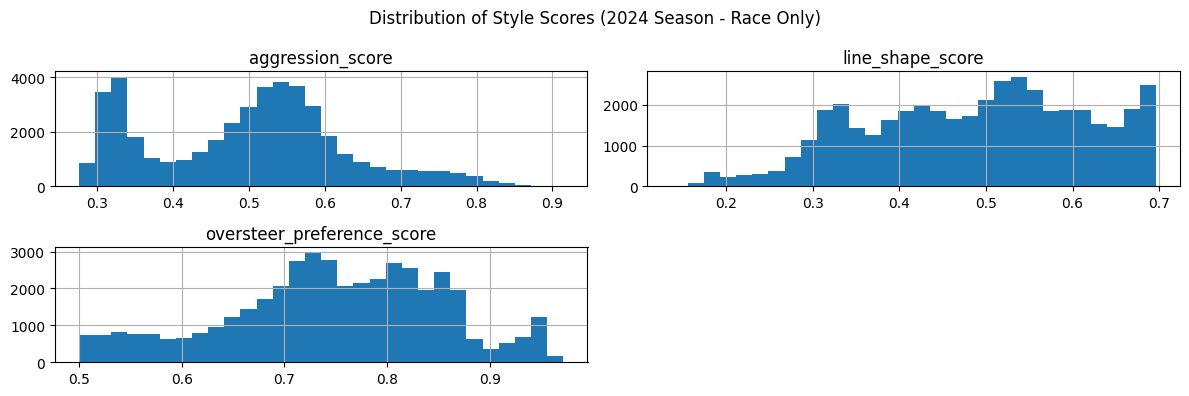

In [30]:

# 2. Distribution of target scores
labels[['aggression_score', 'line_shape_score', 'oversteer_preference_score']].hist(figsize=(12, 4), bins=30)
plt.suptitle('Distribution of Style Scores (2024 Season - Race Only)')
plt.tight_layout()
plt.show()

In [31]:
# 3. Summary statistics
print("\n=== Target Score Statistics ===")
print(labels[['aggression_score', 'line_shape_score', 'oversteer_preference_score']].describe())


=== Target Score Statistics ===
       aggression_score  line_shape_score  oversteer_preference_score
count      43444.000000      43444.000000                43444.000000
mean           0.497224          0.486243                    0.747630
std            0.128366          0.126661                    0.104855
min            0.276134          0.136912                    0.500038
25%            0.375376          0.389014                    0.685363
50%            0.513387          0.500000                    0.750788
75%            0.575461          0.586263                    0.823739
max            0.914373          0.696088                    0.971360


In [32]:
# 4. Driver style comparison (Turn 1 benchmark)
turn_1 = labels[labels['corner_number'] == 1]

# Define target metric columns
style_cols = ['aggression_score', 'line_shape_score', 'oversteer_preference_score']

# Group by driver, calculate mean across all style metrics, and sort by Aggression
turn_1_driver_styles = (
    turn_1.groupby('driver')[style_cols]
    .mean()
    .sort_values(by='aggression_score', ascending=False)
)

print("\n=== Top Drivers by Turn 1 Style Profile ===")
print(turn_1_driver_styles.head(20).round(4))



=== Top Drivers by Turn 1 Style Profile ===
        aggression_score  line_shape_score  oversteer_preference_score
driver                                                                
LAW               0.5377            0.5263                      0.7189
OCO               0.5110            0.4280                      0.7906
BOT               0.5092            0.4390                      0.7835
PIA               0.5090            0.4490                      0.7813
HUL               0.5084            0.4340                      0.7954
NOR               0.5072            0.4352                      0.7883
SAR               0.5024            0.4078                      0.8060
PER               0.5021            0.4310                      0.7948
MAG               0.5006            0.4432                      0.7815
ALO               0.5004            0.4399                      0.7824
RIC               0.4995            0.4256                      0.7909
STR               0.4992        

In [33]:
# 5. Session type verification (Should be exclusively 'R')
print("\n=== Session Type Breakdown ===")
print(labels['session_type'].value_counts())


=== Session Type Breakdown ===
session_type
R    43444
Name: count, dtype: int64
